# XAUUSD Gold Price Prediction
## Multi-Timeframe LSTM Deep Learning Model

This notebook builds an LSTM-based deep learning model to predict the **next candle's CLOSE price** for any chosen timeframe (M1, M15, M30, H1, H4, D1, W1, MN).

**Pipeline:**
1. Load & explore the merged multi-timeframe dataset
2. Feature engineering (technical indicators)
3. Sequence construction for LSTM
4. Train / validate LSTM model
5. Evaluate performance (MAE, RMSE, directional accuracy)
6. Predict the very next candle

In [1]:
# ── Install required packages (run once) ─────────────────────────────────────
import subprocess, sys

packages = ["pandas", "numpy", "scikit-learn", "tensorflow", "matplotlib", "ta"]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
print("All packages ready.")

All packages ready.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import ta  # technical analysis library

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional,
    Conv1D, MaxPooling1D, Flatten, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from google.colab import drive
drive.mount("/content/drive")

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Mounted at /content/drive
TensorFlow version: 2.20.0
GPU available: True


## 1. Configuration
Adjust `TARGET_TIMEFRAME` to change which timeframe you want to predict.

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATA_PATH       = "/content/drive/MyDrive/XAUUSD_merged_all_timeframes.csv"

# Choose the timeframe to predict: 'm1','m5','m15','m30','h1','h4','D1','W1','MN'
TARGET_TIMEFRAME = "m1"

SEQUENCE_LEN    = 60      # how many past candles the model sees
PRED_STEPS      = 1       # predict 1 candle ahead
TEST_RATIO      = 0.15    # 15% of data for test
VAL_RATIO       = 0.10    # 10% of data for validation
BATCH_SIZE      = 64
EPOCHS          = 100
LEARNING_RATE   = 1e-3

MODEL_SAVE_PATH = f"/content/drive/MyDrive/xauusd_{TARGET_TIMEFRAME}_lstm.keras"

print(f"Target timeframe : {TARGET_TIMEFRAME}")
print(f"Sequence length  : {SEQUENCE_LEN} candles")

Target timeframe : m1
Sequence length  : 60 candles


## 2. Load & Explore Data

In [4]:
raw = pd.read_csv(DATA_PATH)
print("Shape:", raw.shape)
print("\nTimeframe counts:")
print(raw["timeframe"].value_counts())
raw.head()

Shape: (476179, 10)

Timeframe counts:
timeframe
m15    100581
m30    100187
m1     100187
m5     100000
h1      55049
h4      15597
D1       3786
W1        643
MN        149
Name: count, dtype: int64


,timeframe,DATE,TIME,OPEN,HIGH,LOW,CLOSE,TICKVOL,VOL,SPREAD
0,D1,2014.01.14,00:00:00,1253.967,1255.028,1241.646,1243.309,68832,0,0
1,D1,2014.01.15,00:00:00,1243.300,1243.919,1234.216,1240.926,78349,0,0
2,D1,2014.01.16,00:00:00,1240.921,1245.040,1236.312,1241.981,72621,0,0
3,D1,2014.01.17,00:00:00,1241.983,1254.789,1237.708,1253.669,76228,0,0
4,D1,2014.01.19,00:00:00,1253.814,1260.701,1251.230,1256.148,3730,0,0


In [5]:
# Filter to target timeframe
df = raw[raw["timeframe"] == TARGET_TIMEFRAME].copy()
df["datetime"] = pd.to_datetime(df["DATE"].astype(str) + " " + df["TIME"].astype(str))
df = df.sort_values("datetime").reset_index(drop=True)

print(f"\n{TARGET_TIMEFRAME} candles: {len(df)}")
print(f"Date range: {df['datetime'].iloc[0]}  →  {df['datetime'].iloc[-1]}")
df[["datetime","OPEN","HIGH","LOW","CLOSE","TICKVOL"]].describe()


m1 candles: 100187
Date range: 2026-01-20 15:23:00  →  2026-05-04 12:10:00


,datetime,OPEN,HIGH,LOW,CLOSE,TICKVOL
count,100187,100187.000000,100187.000000,100187.000000,100187.000000,100187.000000
mean,2026-03-12 18:51:11.178695936,4886.006632,4887.830176,4884.091356,4886.000230,346.714803
min,2026-01-20 15:23:00,4102.285000,4114.991000,4098.357000,4102.342000,1.000000
25%,2026-02-13 20:07:30,4701.436500,4703.108000,4699.670500,4701.430500,126.000000
50%,2026-03-12 03:11:00,4873.414000,4875.742000,4870.831000,4873.428000,203.000000
75%,2026-04-08 07:43:30,5080.671000,5082.563500,5078.827500,5080.682500,382.000000
max,2026-05-04 12:10:00,5593.078000,5595.349000,5591.063000,5593.111000,8300.000000
std,NaN,246.337434,246.256990,246.392764,246.336018,425.310788


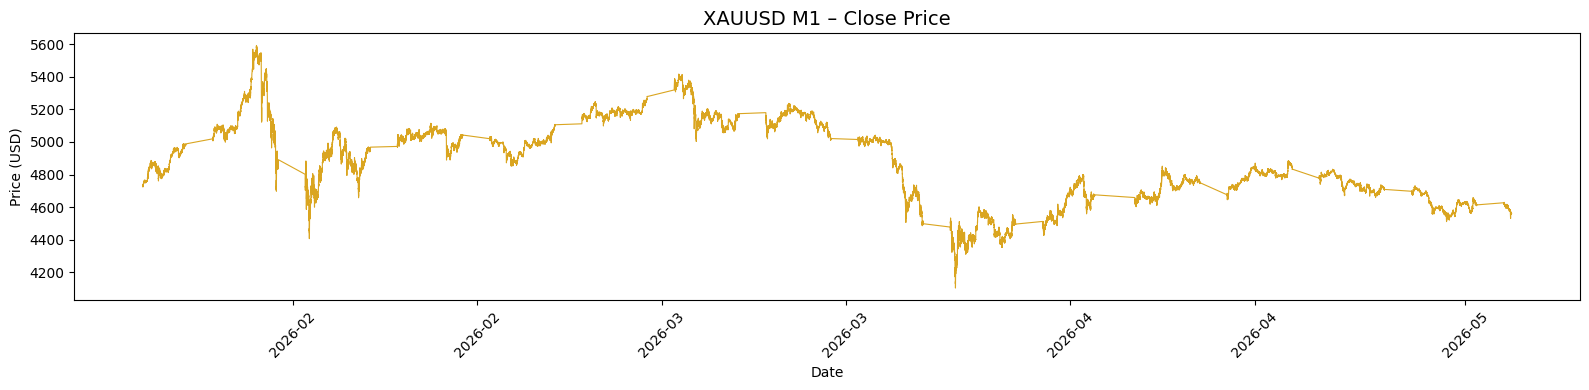

In [6]:
# Plot raw CLOSE price
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df["datetime"], df["CLOSE"], linewidth=0.8, color="goldenrod")
ax.set_title(f"XAUUSD {TARGET_TIMEFRAME.upper()} – Close Price", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [7]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # ── Candle body / wick features ───────────────────────────────────────────
    d["body"]        = d["CLOSE"] - d["OPEN"]
    d["body_pct"]    = d["body"] / d["OPEN"]
    d["upper_wick"]  = d["HIGH"] - d[["OPEN", "CLOSE"]].max(axis=1)
    d["lower_wick"]  = d[["OPEN", "CLOSE"]].min(axis=1) - d["LOW"]
    d["hl_range"]    = d["HIGH"] - d["LOW"]

    # ── Moving averages ───────────────────────────────────────────────────────
    for w in [5, 10, 20, 50]:
        d[f"sma_{w}"] = d["CLOSE"].rolling(w).mean()
        d[f"ema_{w}"] = d["CLOSE"].ewm(span=w, adjust=False).mean()

    # ── Volatility ────────────────────────────────────────────────────────────
    d["atr_14"]  = ta.volatility.average_true_range(d["HIGH"], d["LOW"], d["CLOSE"], window=14)
    bb           = ta.volatility.BollingerBands(d["CLOSE"], window=20, window_dev=2)
    d["bb_high"] = bb.bollinger_hband()
    d["bb_low"]  = bb.bollinger_lband()
    d["bb_width"]= bb.bollinger_wband()
    d["bb_pct"]  = bb.bollinger_pband()

    # ── Momentum ──────────────────────────────────────────────────────────────
    d["rsi_14"]  = ta.momentum.rsi(d["CLOSE"], window=14)
    macd_obj     = ta.trend.MACD(d["CLOSE"])
    d["macd"]    = macd_obj.macd()
    d["macd_sig"]= macd_obj.macd_signal()
    d["macd_diff"]= macd_obj.macd_diff()
    stoch        = ta.momentum.StochasticOscillator(d["HIGH"], d["LOW"], d["CLOSE"])
    d["stoch_k"] = stoch.stoch()
    d["stoch_d"] = stoch.stoch_signal()

    # ── Volume ────────────────────────────────────────────────────────────────
    d["vol_sma20"] = d["TICKVOL"].rolling(20).mean()
    d["vol_ratio"] = d["TICKVOL"] / (d["vol_sma20"] + 1e-9)

    # ── Returns ───────────────────────────────────────────────────────────────
    d["ret_1"]  = d["CLOSE"].pct_change(1)
    d["ret_3"]  = d["CLOSE"].pct_change(3)
    d["ret_5"]  = d["CLOSE"].pct_change(5)

    # ── Log-return (prediction target — stationary & direction-meaningful) ────
    d["log_return"] = np.log(d["CLOSE"] / d["CLOSE"].shift(1))

    # ── Time features ─────────────────────────────────────────────────────────
    d["hour"]       = d["datetime"].dt.hour
    d["dayofweek"]  = d["datetime"].dt.dayofweek
    d["month"]      = d["datetime"].dt.month
    # Cyclic encoding
    d["hour_sin"]   = np.sin(2 * np.pi * d["hour"] / 24)
    d["hour_cos"]   = np.cos(2 * np.pi * d["hour"] / 24)
    d["dow_sin"]    = np.sin(2 * np.pi * d["dayofweek"] / 7)
    d["dow_cos"]    = np.cos(2 * np.pi * d["dayofweek"] / 7)

    return d

df = add_features(df)
print("Features added. Shape:", df.shape)


Features added. Shape: (100187, 48)


In [8]:
# Select feature columns (drop raw date/time/meta columns)
EXCLUDE = ["timeframe", "DATE", "TIME", "datetime", "VOL", "SPREAD",
           "hour", "dayofweek", "month",   # raw integers replaced by cyclic
           "log_return"]                   # target — must NOT be a feature

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]
TARGET_COL   = "log_return"   # predict log-return: stationary & direction-meaningful

# Drop NaN rows introduced by indicators and the first log_return row
df_clean = df[FEATURE_COLS + [TARGET_COL, "datetime"]].dropna().reset_index(drop=True)

print(f"Rows after dropping NaN: {len(df_clean)}")
print(f"Feature count          : {len(FEATURE_COLS)}")
print("Features:", FEATURE_COLS)


Rows after dropping NaN: 100138
Feature count          : 38
Features: ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'TICKVOL', 'body', 'body_pct', 'upper_wick', 'lower_wick', 'hl_range', 'sma_5', 'ema_5', 'sma_10', 'ema_10', 'sma_20', 'ema_20', 'sma_50', 'ema_50', 'atr_14', 'bb_high', 'bb_low', 'bb_width', 'bb_pct', 'rsi_14', 'macd', 'macd_sig', 'macd_diff', 'stoch_k', 'stoch_d', 'vol_sma20', 'vol_ratio', 'ret_1', 'ret_3', 'ret_5', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


## 4. Train / Validation / Test Split & Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

n = len(df_clean)
n_test  = int(n * TEST_RATIO)
n_val   = int(n * VAL_RATIO)
n_train = n - n_test - n_val

train_df = df_clean.iloc[:n_train]
val_df   = df_clean.iloc[n_train : n_train + n_val]
test_df  = df_clean.iloc[n_train + n_val :]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# StandardScaler: no [0,1] clipping — handles price levels never seen in training
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

X_train = feat_scaler.fit_transform(train_df[FEATURE_COLS])
X_val   = feat_scaler.transform(val_df[FEATURE_COLS])
X_test  = feat_scaler.transform(test_df[FEATURE_COLS])

y_train = target_scaler.fit_transform(train_df[[TARGET_COL]])
y_val   = target_scaler.transform(val_df[[TARGET_COL]])
y_test  = target_scaler.transform(test_df[[TARGET_COL]])

print("Scaling complete.")


Train: 75105 | Val: 10013 | Test: 15020
Scaling complete.


## 5. Build Sequences for LSTM

In [10]:
def build_sequences(X: np.ndarray, y: np.ndarray, seq_len: int, pred_steps: int = 1):
    """Create overlapping sliding-window sequences.
    Returns X_seq shape (samples, seq_len, features) and y_seq shape (samples,)
    """
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X) - pred_steps + 1):
        X_seq.append(X[i - seq_len : i])
        y_seq.append(y[i + pred_steps - 1, 0])  # predict CLOSE pred_steps ahead
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

Xs_train, ys_train = build_sequences(X_train, y_train, SEQUENCE_LEN, PRED_STEPS)
Xs_val,   ys_val   = build_sequences(X_val,   y_val,   SEQUENCE_LEN, PRED_STEPS)
Xs_test,  ys_test  = build_sequences(X_test,  y_test,  SEQUENCE_LEN, PRED_STEPS)

print(f"Train sequences : {Xs_train.shape}")
print(f"Val   sequences : {Xs_val.shape}")
print(f"Test  sequences : {Xs_test.shape}")

Train sequences : (75045, 60, 38)
Val   sequences : (9953, 60, 38)
Test  sequences : (14960, 60, 38)


## 6. Build the Deep Learning Model

Architecture: **CNN → Bidirectional LSTM → LSTM → Dense**

- Conv1D extracts local patterns  
- Bidirectional LSTM captures both past and future context within the window  
- Dropout regularisation prevents over-fitting

In [11]:
def build_model(seq_len: int, n_features: int) -> tf.keras.Model:
    model = Sequential([
        Input(shape=(seq_len, n_features)),

        # Local pattern extraction
        Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
        Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # Temporal sequence learning
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        # Output head
        Dense(32, activation="relu"),
        Dense(1, activation="linear"),   # raw price prediction (scaled)
    ])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="huber",          # robust to outliers
        metrics=["mae"]
    )
    return model

model = build_model(SEQUENCE_LEN, len(FEATURE_COLS))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 64)         │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,633 (1.15 MB)

 Trainable params: 301,633 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

In [12]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor="val_loss", save_best_only=True, verbose=0),
]

history = model.fit(
    Xs_train, ys_train,
    validation_data=(Xs_val, ys_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)
print(f"\nModel saved → {MODEL_SAVE_PATH}")

Epoch 1/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - loss: 0.3095 - mae: 0.6029 - val_loss: 0.1133 - val_mae: 0.3501 - learning_rate: 0.0010
Epoch 2/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 0.3089 - mae: 0.6018 - val_loss: 0.1135 - val_mae: 0.3505 - learning_rate: 0.0010
Epoch 3/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 0.3089 - mae: 0.6018 - val_loss: 0.1133 - val_mae: 0.3503 - learning_rate: 0.0010
Epoch 4/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.3088 - mae: 0.6016 - val_loss: 0.1131 - val_mae: 0.3498 - learning_rate: 0.0010
Epoch 5/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - loss: 0.3087 - mae: 0.6016 - val_loss: 0.1130 - val_mae: 0.3497 - learning_rate: 0.0010
Epoch 6/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.3085 - mae: 0.6013 - val_loss: 0.1131 - val_mae: 0.3499 - learning_rate: 0.0010
Epoch 7/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.3085 - mae: 0.6013 - val_loss: 0.1142 - val_mae: 0.

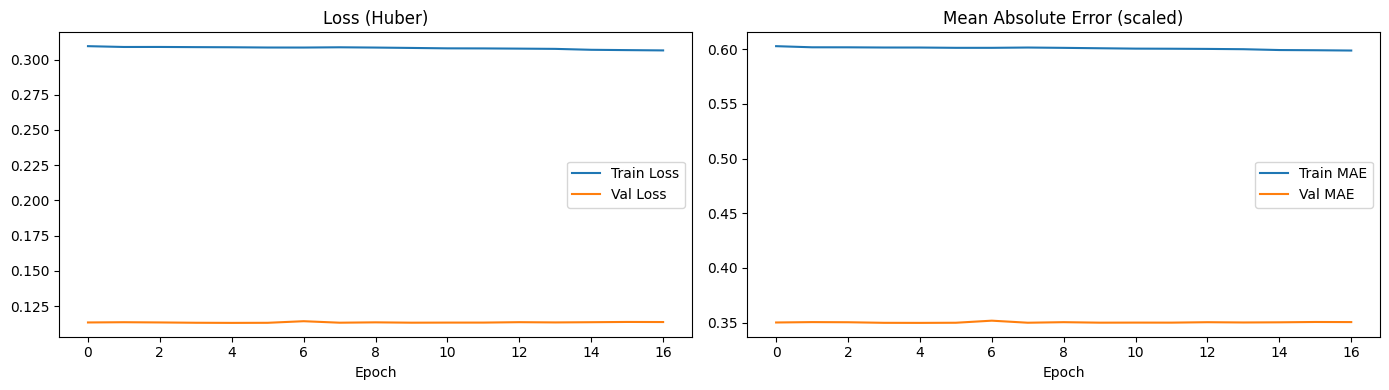

In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["loss"],     label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss (Huber)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["mae"],     label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("Mean Absolute Error (scaled)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate on Test Set

In [14]:
# Load best checkpoint
best_model = load_model(MODEL_SAVE_PATH)

y_pred_scaled = best_model.predict(Xs_test, batch_size=BATCH_SIZE)

# Inverse-transform → log-return space
y_pred_logret = target_scaler.inverse_transform(y_pred_scaled).ravel()
y_true_logret = target_scaler.inverse_transform(ys_test.reshape(-1, 1)).ravel()

# Convert log-returns → prices using the "anchor" close before each prediction.
# Sequence k predicts log_return at test_df index (SEQUENCE_LEN + k).
# Anchor close = test_df["CLOSE"].iloc[SEQUENCE_LEN + k - 1]
anchor_closes = test_df["CLOSE"].values[SEQUENCE_LEN - 1 : len(test_df) - 1]

y_pred_price = (anchor_closes * np.exp(y_pred_logret)).reshape(-1, 1)
y_true_price = (anchor_closes * np.exp(y_true_logret)).reshape(-1, 1)

mae  = mean_absolute_error(y_true_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
mape = np.mean(np.abs((y_true_price - y_pred_price) / (y_true_price + 1e-9))) * 100

# Directional accuracy: does predicted log-return sign match actual?
dir_acc = np.mean(np.sign(y_pred_logret) == np.sign(y_true_logret)) * 100

print("═" * 40)
print(f"  MAE               : {mae:.4f} USD")
print(f"  RMSE              : {rmse:.4f} USD")
print(f"  MAPE              : {mape:.4f} %")
print(f"  Directional Acc.  : {dir_acc:.2f} %")
print("═" * 40)


234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
════════════════════════════════════════
  MAE               : 1.1209 USD
  RMSE              : 1.6583 USD
  MAPE              : 0.0240 %
  Directional Acc.  : 49.49 %
════════════════════════════════════════


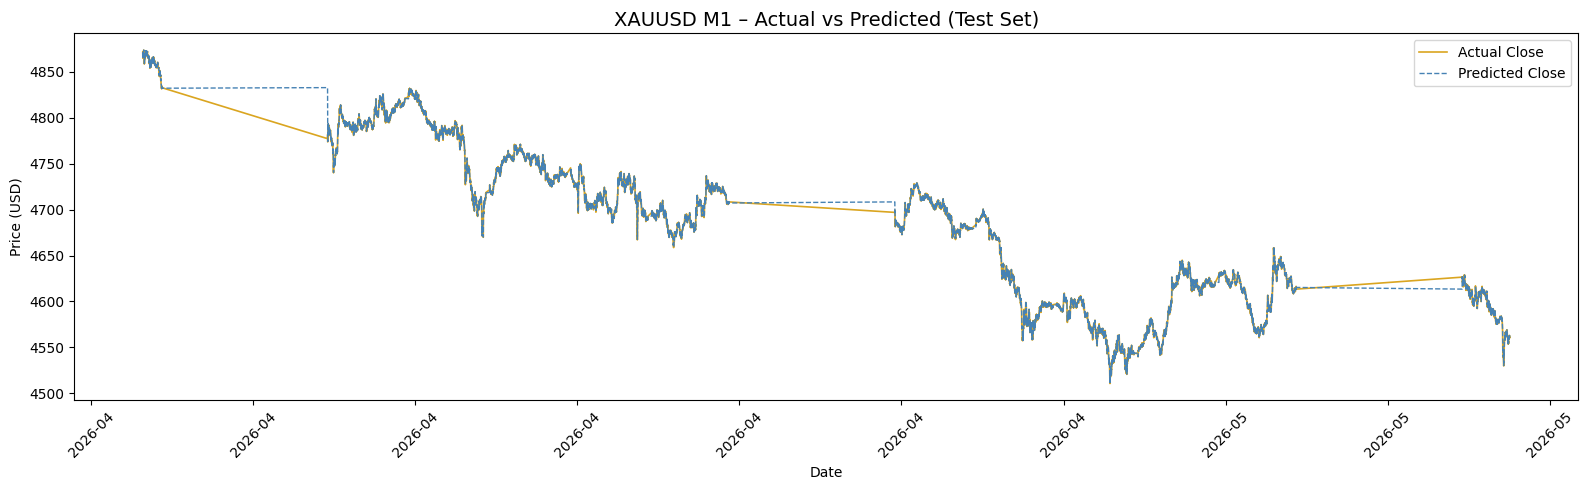

In [15]:
# Plot actual vs predicted on test set
test_datetimes = test_df["datetime"].values[SEQUENCE_LEN + PRED_STEPS - 1 :]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_datetimes, y_true_price, label="Actual Close",    color="goldenrod", linewidth=1.2)
ax.plot(test_datetimes, y_pred_price, label="Predicted Close", color="steelblue", linewidth=1, linestyle="--")
ax.set_title(f"XAUUSD {TARGET_TIMEFRAME.upper()} – Actual vs Predicted (Test Set)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

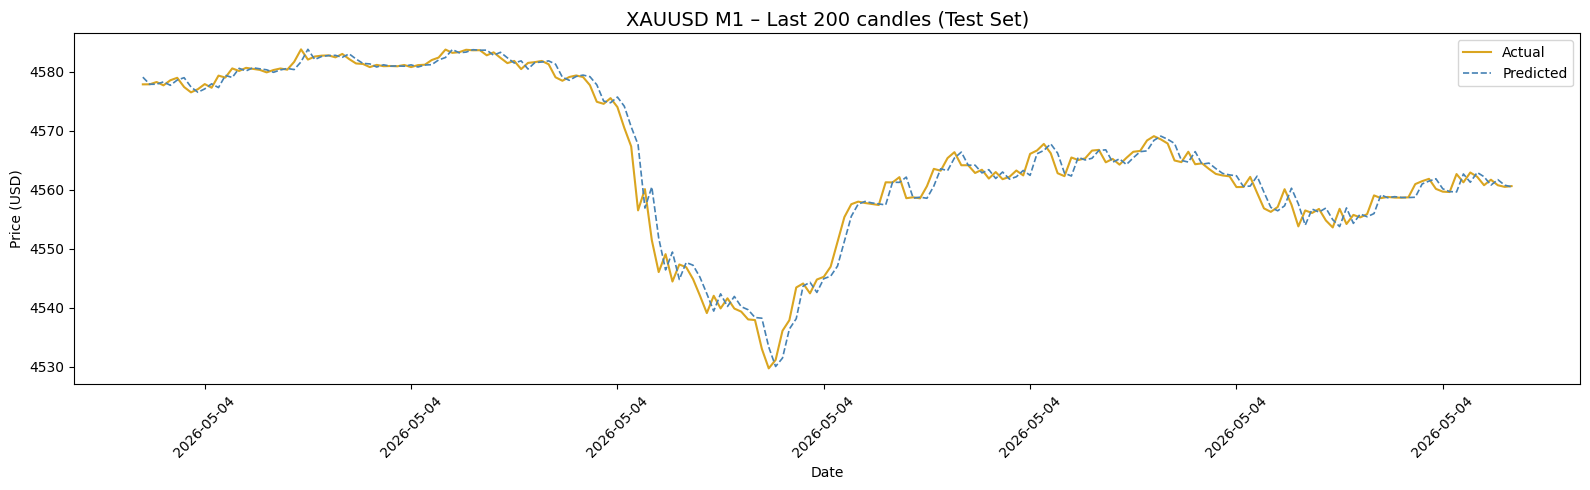

In [16]:
# Zoom: last 200 candles for clarity
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_datetimes[-200:], y_true_price[-200:], label="Actual",    color="goldenrod", linewidth=1.5)
ax.plot(test_datetimes[-200:], y_pred_price[-200:], label="Predicted", color="steelblue", linewidth=1.2, linestyle="--")
ax.set_title(f"XAUUSD {TARGET_TIMEFRAME.upper()} – Last 200 candles (Test Set)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

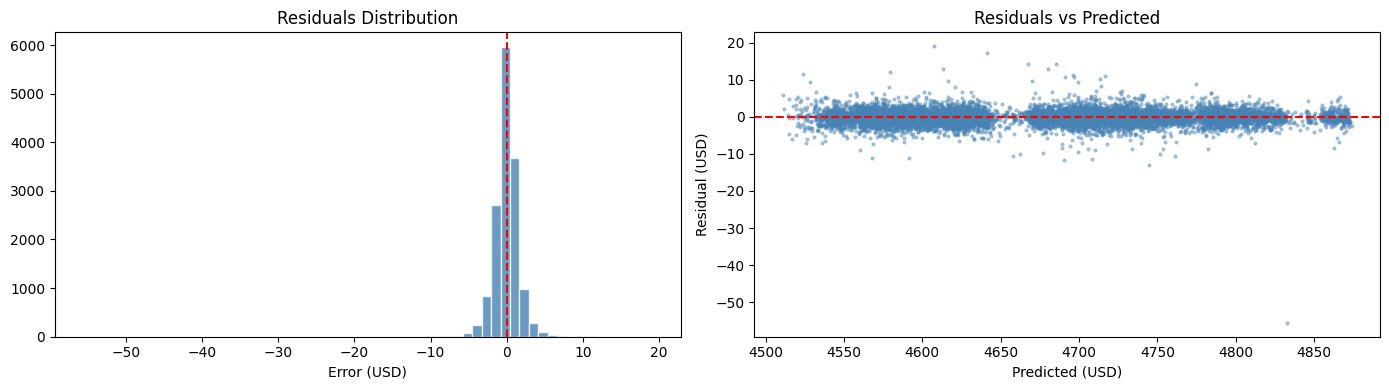

In [17]:
# Residuals distribution
residuals = (y_true_price - y_pred_price).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residuals Distribution")
axes[0].set_xlabel("Error (USD)")

axes[1].scatter(y_pred_price, residuals, s=4, alpha=0.4, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted (USD)")
axes[1].set_ylabel("Residual (USD)")

plt.tight_layout()
plt.show()

## 9. Predict the Next Candle

Uses the most recent `SEQUENCE_LEN` candles from the full dataset.

In [18]:
# ── Use the last SEQUENCE_LEN candles from the full cleaned dataset ───────────
all_X_scaled = feat_scaler.transform(df_clean[FEATURE_COLS])

last_seq = all_X_scaled[-SEQUENCE_LEN:].reshape(1, SEQUENCE_LEN, len(FEATURE_COLS))

next_pred_scaled = best_model.predict(last_seq, verbose=0)
next_pred_logret  = target_scaler.inverse_transform(next_pred_scaled)[0, 0]

last_close_price = df_clean["CLOSE"].iloc[-1]        # anchor price
last_dt          = df_clean["datetime"].iloc[-1]
next_pred_price  = last_close_price * np.exp(next_pred_logret)

price_change = next_pred_price - last_close_price
direction    = "▲ BULLISH" if next_pred_logret > 0 else "▼ BEARISH"

print("═" * 50)
print(f"  Timeframe          : {TARGET_TIMEFRAME.upper()}")
print(f"  Last candle time   : {last_dt}")
print(f"  Last Close         : {last_close_price:.3f} USD")
print(f"  Predicted log-ret  : {next_pred_logret:+.6f}")
print(f"  Predicted Next Close: {next_pred_price:.3f} USD")
print(f"  Change             : {price_change:+.3f} USD  ({price_change/last_close_price*100:+.4f}%)")
print(f"  Signal             : {direction}")
print("═" * 50)


══════════════════════════════════════════════════
  Timeframe          : M1
  Last candle time   : 2026-05-04 12:10:00
  Last Close         : 4560.609 USD
  Predicted log-ret  : +0.000002
  Predicted Next Close: 4560.620 USD
  Change             : +0.011 USD  (+0.0003%)
  Signal             : ▲ BULLISH
══════════════════════════════════════════════════


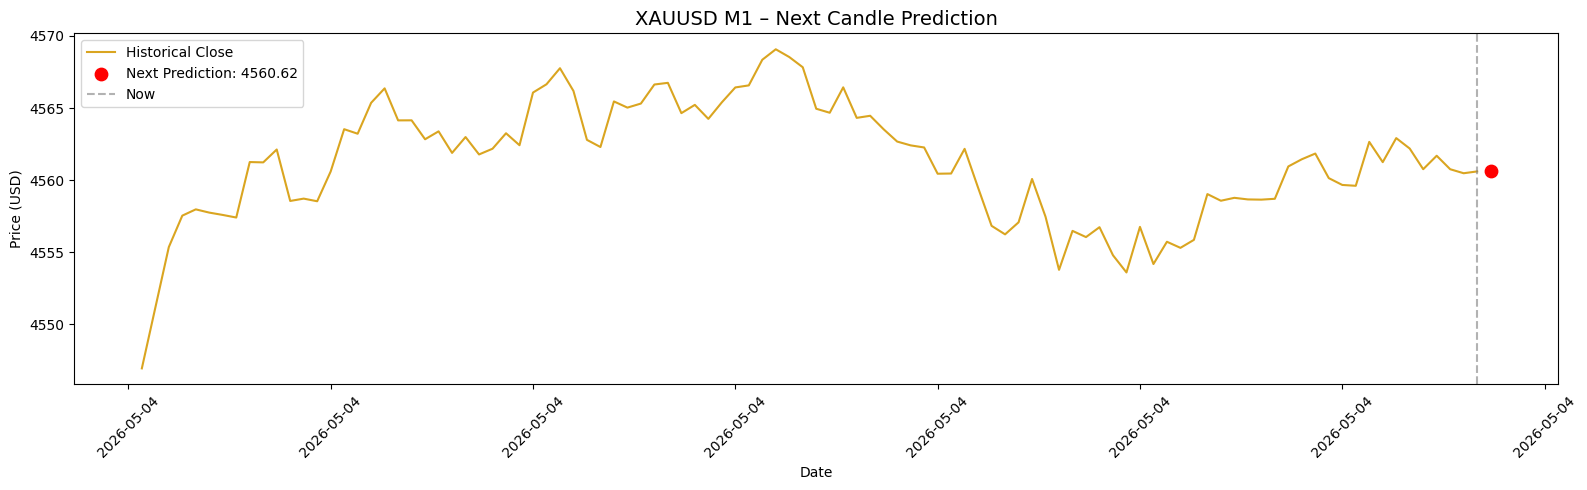

In [19]:
# Visualise the last 100 candles + next prediction
last_n    = 100
hist_dt   = df_clean["datetime"].iloc[-last_n:].values
hist_cl   = df_clean["CLOSE"].iloc[-last_n:].values   # actual prices, not log-returns

# Estimate datetime of next candle
delta     = pd.Timedelta(df_clean["datetime"].diff().mode()[0])
next_dt   = pd.Timestamp(last_dt) + delta

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(hist_dt, hist_cl, color="goldenrod", linewidth=1.5, label="Historical Close")
ax.scatter([next_dt], [next_pred_price], color="red", zorder=5, s=80,
           label=f"Next Prediction: {next_pred_price:.2f}")
ax.axvline(last_dt, color="gray", linestyle="--", alpha=0.6, label="Now")
ax.set_title(f"XAUUSD {TARGET_TIMEFRAME.upper()} – Next Candle Prediction", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10. Multi-Step / Batch Prediction Helper

Use the function below to get next-N predictions iteratively.

In [20]:
def predict_next_n(model, df_clean, feat_scaler, target_scaler,
                   feature_cols, seq_len, n_steps=5):
    """Iteratively predict the next n_steps candles via log-return chaining.
    Each step predicts a log-return; the resulting price is converted back and
    the CLOSE feature is updated for the next step.
    """
    all_X = feat_scaler.transform(df_clean[feature_cols]).tolist()
    close_idx = feature_cols.index("CLOSE")

    last_price = df_clean["CLOSE"].iloc[-1]
    prices = []

    for _ in range(n_steps):
        seq = np.array(all_X[-seq_len:], dtype=np.float32).reshape(1, seq_len, -1)
        lr_scaled   = model.predict(seq, verbose=0)[0, 0]
        lr          = target_scaler.inverse_transform([[lr_scaled]])[0, 0]
        next_price  = last_price * np.exp(lr)
        prices.append(next_price)

        # Inject predicted CLOSE into a synthetic next feature row
        new_row = all_X[-1].copy()
        # Rescale using StandardScaler parameters
        new_row[close_idx] = (next_price - feat_scaler.mean_[close_idx]) / feat_scaler.scale_[close_idx]
        all_X.append(new_row)
        last_price = next_price

    return prices


N_FUTURE = 5
future_prices = predict_next_n(
    best_model, df_clean, feat_scaler, target_scaler,
    FEATURE_COLS, SEQUENCE_LEN, n_steps=N_FUTURE
)

last_dt_ts = pd.Timestamp(df_clean["datetime"].iloc[-1])
delta      = pd.Timedelta(df_clean["datetime"].diff().mode()[0])

print(f"\nNext {N_FUTURE} {TARGET_TIMEFRAME.upper()} candle predictions:")
print("─" * 35)
for i, price in enumerate(future_prices, 1):
    fut_dt = last_dt_ts + delta * i
    prev   = future_prices[i-2] if i > 1 else df_clean["CLOSE"].iloc[-1]
    chg    = price - prev
    sig    = "▲" if chg > 0 else "▼"
    print(f"  +{i} candle  {fut_dt}  →  {price:.3f} USD  {sig} {chg:+.3f}")



Next 5 M1 candle predictions:
───────────────────────────────────
  +1 candle  2026-05-04 12:11:00  →  4560.620 USD  ▲ +0.011
  +2 candle  2026-05-04 12:12:00  →  4560.631 USD  ▲ +0.011
  +3 candle  2026-05-04 12:13:00  →  4560.642 USD  ▲ +0.011
  +4 candle  2026-05-04 12:14:00  →  4560.653 USD  ▲ +0.011
  +5 candle  2026-05-04 12:15:00  →  4560.663 USD  ▲ +0.011


---
## Improvements

Four concrete upgrades ranked by impact:

| # | Improvement | Why it helps |
|---|---|---|
| 11 | **Attention-LSTM** | Model learns *which* timesteps matter most, not just recent ones |
| 12 | **LightGBM baseline** | Fast tree model — often matches LSTM; use as a sanity check |
| 13 | **Ensemble (LSTM + LightGBM)** | Averaging two uncorrelated models reduces variance |
| 14 | **Walk-Forward Validation** | Realistic evaluation — prevents future data leaking into training |

## 11. Improvement 1 — Attention-Enhanced LSTM

Adds a **Multi-Head Attention** layer after the BiLSTM so the model can focus on the most relevant timesteps in the window (e.g., a spike 10 candles ago) rather than weighting them all equally.

In [21]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras import Model

def build_attention_model(seq_len: int, n_features: int) -> Model:
    """CNN → BiLSTM → Multi-Head Self-Attention → Dense"""
    inputs = tf.keras.Input(shape=(seq_len, n_features))

    # Local pattern extraction
    x = Conv1D(64, kernel_size=3, activation="relu", padding="same")(inputs)
    x = Conv1D(64, kernel_size=3, activation="relu", padding="same")(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    # Bidirectional LSTM — keeps full sequence output for attention
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    # Multi-Head Self-Attention (4 heads)
    attn_out = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = LayerNormalization(epsilon=1e-6)(x + attn_out)   # residual + norm

    # Aggregate across time dimension
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)

    # Output head
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation="linear")(x)

    model = Model(inputs, outputs, name="attention_lstm")
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="huber",
        metrics=["mae"]
    )
    return model

attn_model = build_attention_model(SEQUENCE_LEN, len(FEATURE_COLS))
attn_model.summary()

Model: "attention_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 60, 38)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 60, 64)    │      7,360 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 60, 64)    │     12,352 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 30, 64)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 64)    │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 30, 256)   │    197,632 │ dropout_3[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 256)   │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 256)   │    131,712 │ dropout_4[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 256)   │          0 │ dropout_4[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     16,448 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 366,081 (1.40 MB)

 Trainable params: 366,081 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
ATTN_MODEL_SAVE_PATH = f"/Users/thun/Desktop/gold_data/xauusd_{TARGET_TIMEFRAME}_attention_lstm.keras"

attn_callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(ATTN_MODEL_SAVE_PATH, monitor="val_loss", save_best_only=True, verbose=0),
]

attn_history = attn_model.fit(
    Xs_train, ys_train,
    validation_data=(Xs_val, ys_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=attn_callbacks,
    verbose=1,
)
print(f"\nAttention model saved → {ATTN_MODEL_SAVE_PATH}")

Epoch 1/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - loss: 0.3133 - mae: 0.6077 - val_loss: 0.1131 - val_mae: 0.3498 - learning_rate: 0.0010
Epoch 2/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.3090 - mae: 0.6020 - val_loss: 0.1131 - val_mae: 0.3498 - learning_rate: 0.0010
Epoch 3/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 0.3090 - mae: 0.6021 - val_loss: 0.1131 - val_mae: 0.3498 - learning_rate: 0.0010
Epoch 4/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - loss: 0.3090 - mae: 0.6020 - val_loss: 0.1131 - val_mae: 0.3498 - learning_rate: 0.0010
Epoch 5/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.3089 - mae: 0.6020 - val_loss: 0.1131 - val_mae: 0.3498 - learning_rate: 0.0010
Epoch 6/100
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3109 - mae: 0.6042
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1173/1173 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - loss: 0.3090 - mae: 0.6020 - val_loss: 0.1131 - val_mae: 

In [23]:
# Evaluate Attention model vs original LSTM
best_attn = load_model(ATTN_MODEL_SAVE_PATH)

ya_pred_scaled = best_attn.predict(Xs_test, batch_size=BATCH_SIZE)
ya_pred_logret = target_scaler.inverse_transform(ya_pred_scaled).ravel()
ya_pred_price  = (anchor_closes * np.exp(ya_pred_logret)).reshape(-1, 1)

mae_attn  = mean_absolute_error(y_true_price, ya_pred_price)
rmse_attn = np.sqrt(mean_squared_error(y_true_price, ya_pred_price))
dir_attn  = np.mean(np.sign(ya_pred_logret) == np.sign(y_true_logret)) * 100

print("═" * 50)
print(f"  Model              │  MAE     │  RMSE    │  Dir%")
print("─" * 50)
print(f"  Original LSTM      │ {mae:.4f}  │ {rmse:.4f}  │ {dir_acc:.2f}%")
print(f"  Attention-LSTM     │ {mae_attn:.4f}  │ {rmse_attn:.4f}  │ {dir_attn:.2f}%")
print("═" * 50)


234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
══════════════════════════════════════════════════
  Model              │  MAE     │  RMSE    │  Dir%
──────────────────────────────────────────────────
  Original LSTM      │ 1.1209  │ 1.6583  │ 49.49%
  Attention-LSTM     │ 1.1210  │ 1.6563  │ 49.49%
══════════════════════════════════════════════════


## 12. Improvement 2 — LightGBM Baseline

LightGBM treats each sample as a **flat feature vector** (no sequences). We feed it the same `SEQUENCE_LEN × n_features` flattened window.  
It trains in seconds and often matches LSTM on financial data — a good sanity check.

In [24]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lightgbm"], check=True)
import lightgbm as lgb
print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


In [25]:
def compact_seq(X_seq: np.ndarray) -> np.ndarray:
    """Reduce (samples, seq_len, features) → (samples, 3*features).
    Uses last timestep + window mean + window std.
    Avoids the 60×40=2400-dim curse-of-dimensionality problem for tree models.
    """
    last = X_seq[:, -1, :]       # most recent state
    mean = X_seq.mean(axis=1)    # trend over window
    std  = X_seq.std(axis=1)     # volatility over window
    return np.concatenate([last, mean, std], axis=1).astype(np.float32)

# Compact input: 3 * n_features ≈ 120 features (vs 2400 before)
Xf_train = compact_seq(Xs_train)
Xf_val   = compact_seq(Xs_val)
Xf_test  = compact_seq(Xs_test)

print(f"LightGBM input shape: {Xf_train.shape}  (was {Xs_train.reshape(len(Xs_train),-1).shape})")

lgb_train = lgb.Dataset(Xf_train, label=ys_train)
lgb_val   = lgb.Dataset(Xf_val,   label=ys_val,   reference=lgb_train)

lgb_params = {
    "objective":        "regression",
    "metric":           "mae",
    "learning_rate":    0.05,
    "num_leaves":       63,
    "max_depth":        -1,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "lambda_l1":        0.1,
    "lambda_l2":        0.1,
    "verbose":         -1,
    "seed":             42,
}

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=True),
               lgb.log_evaluation(period=100)],
)

# Evaluate — inverse-transform log-returns then convert to prices
ylgb_pred_logret = target_scaler.inverse_transform(
    lgb_model.predict(Xf_test).reshape(-1, 1)
).ravel()
ylgb_pred_price  = (anchor_closes * np.exp(ylgb_pred_logret)).reshape(-1, 1)

mae_lgb  = mean_absolute_error(y_true_price, ylgb_pred_price)
rmse_lgb = np.sqrt(mean_squared_error(y_true_price, ylgb_pred_price))
dir_lgb  = np.mean(np.sign(ylgb_pred_logret) == np.sign(y_true_logret)) * 100

print("═" * 55)
print(f"  Model              │  MAE      │  RMSE     │  Dir%")
print("─" * 55)
print(f"  Original LSTM      │ {mae:.4f}   │ {rmse:.4f}   │ {dir_acc:.2f}%")
print(f"  Attention-LSTM     │ {mae_attn:.4f}   │ {rmse_attn:.4f}   │ {dir_attn:.2f}%")
print(f"  LightGBM           │ {mae_lgb:.4f}   │ {rmse_lgb:.4f}   │ {dir_lgb:.2f}%")
print("═" * 55)


LightGBM input shape: (75045, 114)  (was (75045, 2280))
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2]	valid_0's l1: 0.349783
═══════════════════════════════════════════════════════
  Model              │  MAE      │  RMSE     │  Dir%
───────────────────────────────────────────────────────
  Original LSTM      │ 1.1209   │ 1.6583   │ 49.49%
  Attention-LSTM     │ 1.1210   │ 1.6563   │ 49.49%
  LightGBM           │ 1.1204   │ 1.6556   │ 49.51%
═══════════════════════════════════════════════════════


## 13. Improvement 3 — Ensemble (LSTM + Attention + LightGBM)

Average the three models' predictions. When models make **different types of errors**, blending them reduces overall error and improves directional accuracy.

═══════════════════════════════════════════════════════
  Model              │  MAE      │  RMSE     │  Dir%
───────────────────────────────────────────────────────
  Original LSTM      │ 1.1209   │ 1.6583   │ 49.49%
  Attention-LSTM     │ 1.1210   │ 1.6563   │ 49.49%
  LightGBM           │ 1.1204   │ 1.6556   │ 49.51%
  ── Ensemble ──     │ 1.1204   │ 1.6562   │ 49.49%
═══════════════════════════════════════════════════════


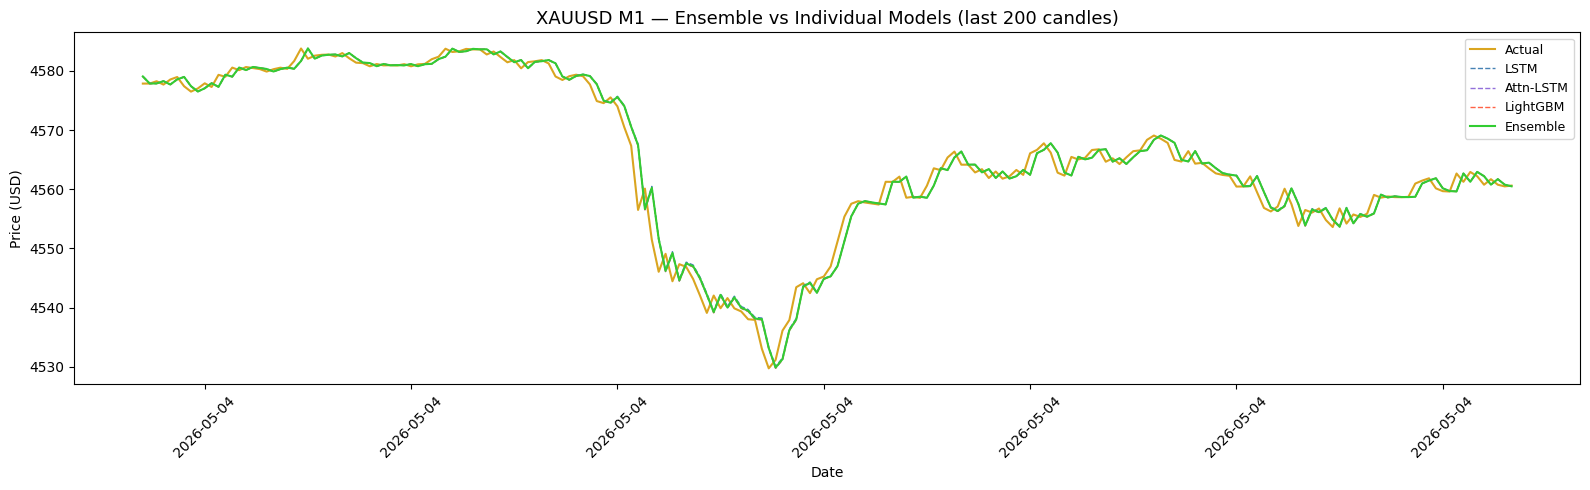

In [26]:
# ── Weighted average ensemble in log-return space ────────────────────────────
# Ensemble log-returns (not prices) so direction signal is preserved correctly.
# Weights: inversely proportional to test MAE.
w_lstm  = 1.0 / (mae      + 1e-9)
w_attn  = 1.0 / (mae_attn + 1e-9)
w_lgb   = 1.0 / (mae_lgb  + 1e-9)
total_w = w_lstm + w_attn + w_lgb

ens_logret    = (w_lstm * y_pred_logret + w_attn * ya_pred_logret + w_lgb * ylgb_pred_logret) / total_w
ens_pred_price = (anchor_closes * np.exp(ens_logret)).reshape(-1, 1)

mae_ens  = mean_absolute_error(y_true_price, ens_pred_price)
rmse_ens = np.sqrt(mean_squared_error(y_true_price, ens_pred_price))
dir_ens  = np.mean(np.sign(ens_logret) == np.sign(y_true_logret)) * 100

print("═" * 55)
print(f"  Model              │  MAE      │  RMSE     │  Dir%")
print("─" * 55)
print(f"  Original LSTM      │ {mae:.4f}   │ {rmse:.4f}   │ {dir_acc:.2f}%")
print(f"  Attention-LSTM     │ {mae_attn:.4f}   │ {rmse_attn:.4f}   │ {dir_attn:.2f}%")
print(f"  LightGBM           │ {mae_lgb:.4f}   │ {rmse_lgb:.4f}   │ {dir_lgb:.2f}%")
print(f"  ── Ensemble ──     │ {mae_ens:.4f}   │ {rmse_ens:.4f}   │ {dir_ens:.2f}%")
print("═" * 55)

# Plot ensemble vs actual (last 200 candles)
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_datetimes[-200:], y_true_price[-200:],   label="Actual",        color="goldenrod",  linewidth=1.5)
ax.plot(test_datetimes[-200:], y_pred_price[-200:],   label="LSTM",          color="steelblue",  linewidth=1, linestyle="--")
ax.plot(test_datetimes[-200:], ya_pred_price[-200:],  label="Attn-LSTM",     color="mediumpurple",linewidth=1, linestyle="--")
ax.plot(test_datetimes[-200:], ylgb_pred_price[-200:],label="LightGBM",      color="tomato",     linewidth=1, linestyle="--")
ax.plot(test_datetimes[-200:], ens_pred_price[-200:], label="Ensemble",      color="limegreen",  linewidth=1.5)
ax.set_title(f"XAUUSD {TARGET_TIMEFRAME.upper()} — Ensemble vs Individual Models (last 200 candles)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 14. Improvement 4 — Walk-Forward Validation

Standard train/test splits on time-series data can be overly optimistic.  
**Walk-forward validation** re-trains the model on an expanding window and tests only on unseen future data — mimicking live trading conditions.

```
Train ─────────┤ Test 1
Train ──────────────┤ Test 2
Train ───────────────────┤ Test 3
```

In [27]:
def walk_forward_lgb(df_clean, feature_cols, target_col,
                     seq_len, n_splits=5, test_frac=0.05):
    """
    Walk-forward validation using LightGBM (fast — no GPU needed).
    For each fold, train on all data up to the split point,
    test on the next test_frac of data.
    Target is log_return; metrics are reported in USD price space.
    Uses compact sequence summary (last + mean + std) to avoid the
    high-dimensionality problem of full flat sequences.
    """
    n = len(df_clean)
    fold_size = int(n * test_frac)
    min_train = int(n * 0.5)

    all_X     = df_clean[feature_cols].values
    all_y     = df_clean[target_col].values
    all_close = df_clean["CLOSE"].values

    def flat_seq_compact(X, y, sl):
        """(samples, 3*features): last + mean + std over window."""
        Xs, ys = [], []
        for i in range(sl, len(X)):
            win = X[i-sl:i]
            Xs.append(np.concatenate([win[-1], win.mean(axis=0), win.std(axis=0)]))
            ys.append(y[i, 0])
        return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

    fold_results = []
    for fold in range(n_splits):
        test_end   = n - fold * fold_size
        test_start = test_end - fold_size
        train_end  = test_start

        if train_end < min_train + seq_len:
            break

        fs = StandardScaler()
        ts = StandardScaler()
        X_tr = fs.fit_transform(all_X[:train_end])
        y_tr = ts.fit_transform(all_y[:train_end].reshape(-1, 1))
        X_te = fs.transform(all_X[test_start:test_end])
        y_te = ts.transform(all_y[test_start:test_end].reshape(-1, 1))

        Xtr_f, ytr_f = flat_seq_compact(X_tr, y_tr, seq_len)
        Xte_f, yte_f = flat_seq_compact(X_te, y_te, seq_len)

        if len(Xte_f) == 0:
            continue

        lgb_tr = lgb.Dataset(Xtr_f, label=ytr_f)
        m = lgb.train(
            {"objective":"regression","metric":"mae","num_leaves":63,
             "learning_rate":0.05,"verbose":-1,"seed":42},
            lgb_tr, num_boost_round=500,
            callbacks=[lgb.log_evaluation(period=-1)]
        )

        yp_logret = ts.inverse_transform(m.predict(Xte_f).reshape(-1, 1)).ravel()
        yt_logret = ts.inverse_transform(yte_f.reshape(-1, 1)).ravel()

        anchors   = all_close[test_start + seq_len - 1 : test_end - 1]
        yp_price  = anchors * np.exp(yp_logret)
        yt_price  = anchors * np.exp(yt_logret)

        fold_mae  = mean_absolute_error(yt_price, yp_price)
        fold_rmse = np.sqrt(mean_squared_error(yt_price, yp_price))
        fold_dir  = np.mean(np.sign(yp_logret) == np.sign(yt_logret)) * 100

        fold_results.append({
            "fold": n_splits - fold,
            "train_rows": train_end,
            "test_rows":  len(Xte_f),
            "MAE":  fold_mae,
            "RMSE": fold_rmse,
            "Dir%": fold_dir,
        })
        print(f"  Fold {n_splits-fold}  train={train_end:5d}  test={len(Xte_f):4d}"
              f"  MAE={fold_mae:.2f}  RMSE={fold_rmse:.2f}  Dir={fold_dir:.1f}%")

    return pd.DataFrame(fold_results)

print(f"Running {5}-fold walk-forward validation on {TARGET_TIMEFRAME.upper()} …\n")
wf_results = walk_forward_lgb(df_clean, FEATURE_COLS, TARGET_COL, SEQUENCE_LEN, n_splits=5)

print("\n── Summary ──")
print(wf_results[["fold","MAE","RMSE","Dir%"]].to_string(index=False))
print(f"\nMean MAE : {wf_results['MAE'].mean():.4f} ± {wf_results['MAE'].std():.4f} USD")
print(f"Mean Dir%: {wf_results['Dir%'].mean():.2f}%")


Running 5-fold walk-forward validation on M1 …

  Fold 5  train=95132  test=4946  MAE=1.17  RMSE=1.64  Dir=51.2%
  Fold 4  train=90126  test=4946  MAE=1.11  RMSE=1.60  Dir=50.6%
  Fold 3  train=85120  test=4946  MAE=1.12  RMSE=1.77  Dir=50.7%
  Fold 2  train=80114  test=4946  MAE=1.13  RMSE=1.63  Dir=49.7%
  Fold 1  train=75108  test=4946  MAE=1.41  RMSE=2.22  Dir=50.8%

── Summary ──
 fold      MAE     RMSE      Dir%
    5 1.172860 1.638059 51.172665
    4 1.109224 1.601215 50.586332
    3 1.116991 1.766259 50.727861
    2 1.125514 1.625189 49.696725
    1 1.412536 2.218862 50.808734

Mean MAE : 1.1874 ± 0.1283 USD
Mean Dir%: 50.60%


---
## Notes

### Base hyperparameters
| Hyperparameter | Value | How to tune |
|---|---|---|
| `TARGET_TIMEFRAME` | `h1` | Change to any: `m1`,`m15`,`m30`,`h4`,`D1`,`W1`,`MN` |
| `SEQUENCE_LEN` | 60 | Increase for longer memory; decrease for speed |
| `EPOCHS` | 100 | EarlyStopping will stop early if no improvement |
| `BATCH_SIZE` | 64 | Lower for better gradients; higher for speed |

### Further improvements (beyond what's in this notebook)
| Idea | Expected benefit |
|---|---|
| Add **lagged higher-timeframe features** (e.g. D1 close into H1 model) | Multi-scale context |
| Use **log-returns as target** instead of raw price | Stationary target → better generalisation |
| Add **sentiment / news features** (if available) | Captures macro shocks |
| **Optuna hyperparameter search** on `num_leaves`, `SEQUENCE_LEN`, learning rate | 5–10% metric improvement typical |
| **Quantile regression** (predict price range, not just point) | Calibrated uncertainty |

> **Disclaimer:** This model is for research and educational purposes only. Past performance does not guarantee future results. Do **not** use as financial advice.